# GP `p_vis` Sandbox (Clean Version)

This notebook is intentionally simplified:
- Single GP visibility model (`p_vis(x,y)`), no 5-option branches.
- ET1 vs ET2 comparison with explicit risk and ambiguity logging.
- Time-varying goal prior variance (more goal-focused near the end).
- Planned path vs executed path visualization.


In [10]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import minimize

np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.2

cwd = Path.cwd().resolve()
if (cwd / 'scripts').exists():
    scripts_dir = cwd / 'scripts'
elif cwd.name == 'scripts':
    scripts_dir = cwd
else:
    scripts_dir = cwd

if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

from botnav_efe_helpers import PlanarCamera
from botnav_efe_jax import ambiguity_jax, make_homography_g_jax


In [11]:
# Scenario, camera and dynamics setup

cam_pos = np.array([0.0, 0.0, 2.0])
look_at = np.array([0.0, -2.0, 0.0])
cam = PlanarCamera(
    cam_pos=cam_pos,
    look_at=look_at,
    img_width=640,
    img_height=480,
    fov_h_rad=np.deg2rad(90.0),
    up_hint=(0.0, 0.0, 1.0),
)

xmin, xmax = -16.5, 16.5
ymin, ymax = -21.0, 1.0
nx, ny = 180, 140
xs = np.linspace(xmin, xmax, nx)
ys = np.linspace(ymin, ymax, ny)
X, Y = np.meshgrid(xs, ys)

dt = 0.2
A = np.array([
    [1.0, 0.0, dt, 0.0],
    [0.0, 1.0, 0.0, dt],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0],
], dtype=float)
B = np.array([
    [0.5 * dt * dt, 0.0],
    [0.0, 0.5 * dt * dt],
    [dt, 0.0],
    [0.0, dt],
], dtype=float)

Q_plan = np.diag([0.02**2, 0.02**2, 0.06**2, 0.06**2])
Q_true = np.diag([0.03**2, 0.03**2, 0.08**2, 0.08**2])
S_init = np.diag([0.5**2, 0.5**2, 0.25**2, 0.25**2])
R_good = np.diag([2.0**2, 2.0**2])

start_state = np.array([0.0, -4.0, 0.0, 0.0], dtype=float)
goal_state = np.array([0.0, -0.8, 0.0, 0.0], dtype=float)
goal_obs = np.array(cam.g(goal_state), dtype=float)

len_horizon = 4
len_trial = 32
u_lims = (-1.0, 1.0)
eta_u = 0.10
maxiter = 24
maxfun = 420
ftol = 1e-6

# Reproducible preset that produced the strongest ET1/ET2 behavior in this notebook
GOOD_RESULTS_PRESET = dict(
    run_idx=0,
    seed=0,
    occ_radius=0.20,
    occ_tau=0.15,
    occ_noise=0.15,
    w_risk=0.03,
    w_amb=1.0,
    w_vis=4.0,
    w_u=1.0,
    goal_std_start=24.0,
    goal_std_mid=20.0,
    goal_std_end=2.5,
    goal_focus_switch=0.72,
    goal_focus_power=3.5,
    zoom_x=(-2.5, 2.5),
    zoom_y=(-6.0, 1.0),
)

# Goal-prior std schedule: deliberately weak early, strong pull near the end
goal_std_start = GOOD_RESULTS_PRESET['goal_std_start']
goal_std_mid = GOOD_RESULTS_PRESET['goal_std_mid']
goal_std_end = GOOD_RESULTS_PRESET['goal_std_end']
goal_focus_switch = GOOD_RESULTS_PRESET['goal_focus_switch']
goal_focus_power = GOOD_RESULTS_PRESET['goal_focus_power']

# Objective term weights (tune these first when one term dominates)
w_risk = GOOD_RESULTS_PRESET['w_risk']
w_amb = GOOD_RESULTS_PRESET['w_amb']
w_vis = GOOD_RESULTS_PRESET['w_vis']
w_u = GOOD_RESULTS_PRESET['w_u']

RUN_CONFIGS = [
    dict(name='run_0', seed=0,  occ_center=np.array([0.0, -2.1]), occ_radius=GOOD_RESULTS_PRESET['occ_radius'], tau=GOOD_RESULTS_PRESET['occ_tau'], ls=1.40, noise=GOOD_RESULTS_PRESET['occ_noise']),
    dict(name='run_1', seed=7,  occ_center=np.array([0.2, -2.4]), occ_radius=0.95, tau=0.18, ls=1.60, noise=0.06),
    dict(name='run_2', seed=19, occ_center=np.array([-0.3, -1.8]), occ_radius=0.70, tau=0.12, ls=1.20, noise=0.04),
]

print('Setup ready. len_trial=', len_trial, ' len_horizon=', len_horizon)
print(f'weights: w_risk={w_risk}, w_amb={w_amb}, w_vis={w_vis}, w_u={w_u}')
print(f'goal std schedule: start={goal_std_start}, mid={goal_std_mid}, end={goal_std_end}, switch={goal_focus_switch}, power={goal_focus_power}')
print('preset: run_idx={run_idx}, seed={seed}, occ_radius={occ_radius}, tau={tau}, noise={noise}, zoom_x={zx}, zoom_y={zy}'.format(
    run_idx=GOOD_RESULTS_PRESET['run_idx'],
    seed=GOOD_RESULTS_PRESET['seed'],
    occ_radius=GOOD_RESULTS_PRESET['occ_radius'],
    tau=GOOD_RESULTS_PRESET['occ_tau'],
    noise=GOOD_RESULTS_PRESET['occ_noise'],
    zx=GOOD_RESULTS_PRESET['zoom_x'],
    zy=GOOD_RESULTS_PRESET['zoom_y'],
))


Setup ready. len_trial= 32  len_horizon= 4
weights: w_risk=0.03, w_amb=1.0, w_vis=4.0, w_u=1.0
goal std schedule: start=24.0, mid=20.0, end=2.5, switch=0.72, power=3.5
preset: run_idx=0, seed=0, occ_radius=0.2, tau=0.15, noise=0.15, zoom_x=(-2.5, 2.5), zoom_y=(-6.0, 1.0)


In [12]:
# GP visibility model

class SimpleRBFGP:
    def __init__(self, length_scale=1.5, signal_var=1.0, noise_var=5e-2, jitter=1e-8):
        self.length_scale = float(length_scale)
        self.signal_var = float(signal_var)
        self.noise_var = float(noise_var)
        self.jitter = float(jitter)
        self.X_train = None
        self.y_mean = None
        self.L = None
        self.alpha = None

    def _kernel(self, Xa, Xb):
        Xa = np.asarray(Xa, dtype=float)
        Xb = np.asarray(Xb, dtype=float)
        d2 = np.sum((Xa[:, None, :] - Xb[None, :, :]) ** 2, axis=2)
        ls2 = max(self.length_scale ** 2, 1e-12)
        return self.signal_var * np.exp(-0.5 * d2 / ls2)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).reshape(-1)
        self.X_train = X
        self.y_mean = float(y.mean())
        y0 = y - self.y_mean

        K = self._kernel(X, X)
        K = K + (self.noise_var + self.jitter) * np.eye(X.shape[0])
        self.L = np.linalg.cholesky(K)
        self.alpha = np.linalg.solve(self.L.T, np.linalg.solve(self.L, y0))
        return self

    def predict(self, X, return_std=False):
        X = np.asarray(X, dtype=float)
        Ks = self._kernel(X, self.X_train)
        mu = self.y_mean + Ks @ self.alpha

        if not return_std:
            return mu

        v = np.linalg.solve(self.L, Ks.T)
        var = np.maximum(self.signal_var - np.sum(v * v, axis=0), 1e-12)
        return mu, np.sqrt(var)


def fit_visibility_model(cfg):
    rng = np.random.default_rng(int(cfg['seed']))
    occ_center = np.asarray(cfg['occ_center'], dtype=float)
    occ_radius = float(cfg['occ_radius'])
    tau = float(cfg['tau'])

    def p_true(xy):
        arr = np.asarray(xy, dtype=float)
        d = np.linalg.norm(arr - occ_center, axis=-1) - occ_radius
        return np.clip(1.0 / (1.0 + np.exp(-d / tau)), 1e-4, 1.0 - 1e-4)

    N_uniform, N_focus, N_inside = 320, 260, 220
    X_uniform = np.column_stack([
        rng.uniform(xmin, xmax, N_uniform),
        rng.uniform(ymin, ymax, N_uniform),
    ])

    X_focus = occ_center + rng.normal(scale=[0.9, 0.9], size=(N_focus, 2))
    X_focus[:, 0] = np.clip(X_focus[:, 0], xmin, xmax)
    X_focus[:, 1] = np.clip(X_focus[:, 1], ymin, ymax)

    ang = rng.uniform(0.0, 2.0 * np.pi, N_inside)
    rad = occ_radius * np.sqrt(rng.uniform(0.0, 1.0, N_inside)) * 0.98
    X_inside = np.column_stack([
        occ_center[0] + rad * np.cos(ang),
        occ_center[1] + rad * np.sin(ang),
    ])

    X_train = np.vstack([X_uniform, X_focus, X_inside])
    p_train = p_true(X_train)
    y_train = (rng.random(X_train.shape[0]) < p_train).astype(float)

    gp = SimpleRBFGP(
        length_scale=float(cfg['ls']),
        signal_var=1.0,
        noise_var=float(cfg['noise']),
    ).fit(X_train, y_train)

    XY = np.column_stack([X.ravel(), Y.ravel()])
    P_mu, P_std = gp.predict(XY, return_std=True)
    P_map = np.clip(P_mu.reshape(X.shape), 1e-4, 1.0 - 1e-4)
    P_std = P_std.reshape(X.shape)

    return dict(
        cfg=cfg,
        gp=gp,
        X_train=X_train,
        y_train=y_train,
        p_train=p_train,
        P_map=P_map,
        P_std=P_std,
        occ_center=occ_center,
        occ_radius=occ_radius,
        tau=tau,
    )


def install_visibility_run(run_idx=0):
    vis = fit_visibility_model(RUN_CONFIGS[run_idx])
    P_map = vis['P_map']
    P_std = vis['P_std']

    p_interp = RegularGridInterpolator((ys, xs), P_map, bounds_error=False, fill_value=None)
    std_interp = RegularGridInterpolator((ys, xs), P_std, bounds_error=False, fill_value=None)

    def p_vis_np_state(m):
        p = float(p_interp([[float(m[1]), float(m[0])]])[0])
        return float(np.clip(p, 1e-4, 1.0 - 1e-4))

    def p_vis_np_xy(xy):
        arr = np.asarray(xy, dtype=float)
        flat = arr.reshape(-1, 2)
        pts = np.column_stack([flat[:, 1], flat[:, 0]])
        out = np.clip(p_interp(pts), 1e-4, 1.0 - 1e-4)
        return out.reshape(arr.shape[:-1])

    def p_std_np_state(m):
        s = float(std_interp([[float(m[1]), float(m[0])]])[0])
        return float(max(s, 1e-6))

    xs_j = jnp.asarray(xs)
    ys_j = jnp.asarray(ys)
    P_j = jnp.asarray(P_map)

    def _bilinear_jax(x, y):
        ix = jnp.clip(jnp.searchsorted(xs_j, x, side='right') - 1, 0, xs_j.shape[0] - 2)
        iy = jnp.clip(jnp.searchsorted(ys_j, y, side='right') - 1, 0, ys_j.shape[0] - 2)

        x0, x1 = xs_j[ix], xs_j[ix + 1]
        y0, y1 = ys_j[iy], ys_j[iy + 1]

        tx = jnp.where(x1 == x0, 0.0, (x - x0) / (x1 - x0))
        ty = jnp.where(y1 == y0, 0.0, (y - y0) / (y1 - y0))

        z00 = P_j[iy, ix]
        z10 = P_j[iy, ix + 1]
        z01 = P_j[iy + 1, ix]
        z11 = P_j[iy + 1, ix + 1]

        return (1 - tx) * (1 - ty) * z00 + tx * (1 - ty) * z10 + (1 - tx) * ty * z01 + tx * ty * z11

    def p_vis_j(m):
        return jnp.clip(_bilinear_jax(m[0], m[1]), 1e-4, 1.0 - 1e-4)

    globals()['ACTIVE_VIS'] = vis
    globals()['P_all'] = P_map
    globals()['P_std_all'] = P_std
    globals()['p_vis_np_state'] = p_vis_np_state
    globals()['p_vis_np_xy'] = p_vis_np_xy
    globals()['p_std_np_state'] = p_std_np_state
    globals()['p_vis_j'] = p_vis_j

    print(
        f"Installed {vis['cfg']['name']} | "
        f"label_mean={vis['y_train'].mean():.3f} | "
        f"map_std={np.std(P_map):.4f}"
    )


install_visibility_run(0)


Installed run_0 | label_mean=0.812 | map_std=0.0407


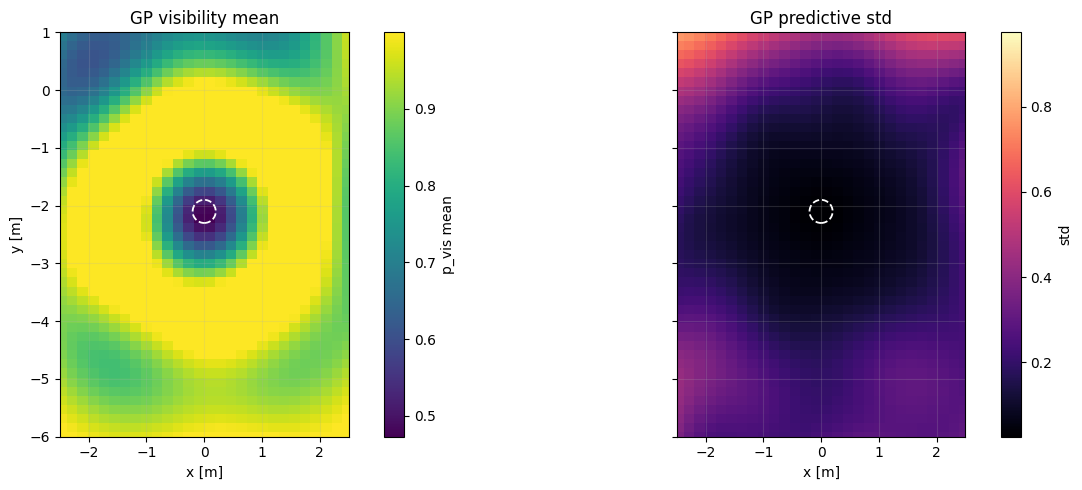

Map std: 0.040710599523380825
p(center): 0.4776576586146775
p(far):    0.9690163356595529


In [13]:
# Visualize GP map and uncertainty

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0), sharex=True, sharey=True)

im0 = axes[0].imshow(P_all, extent=[xmin, xmax, ymin, ymax], origin='lower', cmap='viridis', aspect='equal')
axes[0].add_patch(plt.Circle(ACTIVE_VIS['occ_center'], ACTIVE_VIS['occ_radius'], fill=False, ls='--', lw=1.3, color='white'))
axes[0].set_title('GP visibility mean')
axes[0].set_xlabel('x [m]')
axes[0].set_ylabel('y [m]')
fig.colorbar(im0, ax=axes[0], label='p_vis mean')

im1 = axes[1].imshow(P_std_all, extent=[xmin, xmax, ymin, ymax], origin='lower', cmap='magma', aspect='equal')
axes[1].add_patch(plt.Circle(ACTIVE_VIS['occ_center'], ACTIVE_VIS['occ_radius'], fill=False, ls='--', lw=1.3, color='white'))
axes[1].set_title('GP predictive std')
axes[1].set_xlabel('x [m]')
fig.colorbar(im1, ax=axes[1], label='std')
for ax in axes:
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-6.0, 1.0)

plt.tight_layout()
plt.show()

flatness = float(np.std(P_all))
p_center = p_vis_np_state(np.array([ACTIVE_VIS['occ_center'][0], ACTIVE_VIS['occ_center'][1], 0.0, 0.0]))
p_far = p_vis_np_state(np.array([0.0, -12.0, 0.0, 0.0]))
print('Map std:', flatness)
print('p(center):', p_center)
print('p(far):   ', p_far)
assert flatness > 0.01, 'GP map is too flat.'


In [14]:
# Single GP-driven measurement model

R_bad = np.diag([28.0**2, 28.0**2])


def measurement_model_np(m_pred, S_pred):
    p = p_vis_np_state(m_pred)
    q = 1.0 - p

    R_eff = p * R_good + q * R_bad

    S_eff = S_pred.copy()
    S_eff[0, 0] *= (1.0 + 2.0 * q)
    S_eff[1, 1] *= (1.0 + 2.0 * q)
    S_eff[2, 2] *= (1.0 + 0.8 * q)
    S_eff[3, 3] *= (1.0 + 0.8 * q)

    gain_scale = p

    R_eff = 0.5 * (R_eff + R_eff.T) + 1e-9 * np.eye(2)
    S_eff = 0.5 * (S_eff + S_eff.T) + 1e-9 * np.eye(4)
    return p, R_eff, S_eff, gain_scale


I2_j = jnp.eye(2)
I4_j = jnp.eye(4)
R_good_j = jnp.asarray(R_good)
R_bad_j = jnp.asarray(R_bad)


def measurement_model_j(m_pred, S_pred):
    p = p_vis_j(m_pred)
    q = 1.0 - p

    R_eff = p * R_good_j + q * R_bad_j

    S_eff = S_pred.at[0, 0].set(S_pred[0, 0] * (1.0 + 2.0 * q))
    S_eff = S_eff.at[1, 1].set(S_pred[1, 1] * (1.0 + 2.0 * q))
    S_eff = S_eff.at[2, 2].set(S_pred[2, 2] * (1.0 + 0.8 * q))
    S_eff = S_eff.at[3, 3].set(S_pred[3, 3] * (1.0 + 0.8 * q))

    gain_scale = p
    return p, 0.5 * (R_eff + R_eff.T) + 1e-9 * I2_j, 0.5 * (S_eff + S_eff.T) + 1e-9 * I4_j, gain_scale


m_near = np.array([ACTIVE_VIS['occ_center'][0], ACTIVE_VIS['occ_center'][1], 0.0, 0.0])
m_far = np.array([0.0, -12.0, 0.0, 0.0])
p_n, R_n, _, g_n = measurement_model_np(m_near, S_init)
p_f, R_f, _, g_f = measurement_model_np(m_far, S_init)
print(f'near: p={p_n:.3f}, tr(R)={np.trace(R_n):.2f}, gain_scale={g_n:.3f}')
print(f'far:  p={p_f:.3f}, tr(R)={np.trace(R_f):.2f}, gain_scale={g_f:.3f}')


near: p=0.478, tr(R)=822.85, gain_scale=0.478
far:  p=0.969, tr(R)=56.33, gain_scale=0.969


In [15]:
# EFE core: ET1/ET2, risk/ambiguity decomposition, and goal-variance schedule

g_jax = make_homography_g_jax(cam.H)

A_j = jnp.asarray(A)
B_j = jnp.asarray(B)
Q_plan_j = jnp.asarray(Q_plan)
S_eye = jnp.eye(4)
R_eye = jnp.eye(2)
goal_obs_j = jnp.asarray(goal_obs)


def _sym_np(M):
    return 0.5 * (M + M.T)


def _sym_j(M):
    return 0.5 * (M + M.T)


def safe_inv_j(M, eps=1e-9):
    M = _sym_j(M) + eps * jnp.eye(M.shape[0], dtype=M.dtype)
    return jnp.linalg.inv(M)


def safe_logdet_j(M, eps=1e-9):
    M = _sym_j(M) + eps * jnp.eye(M.shape[0], dtype=M.dtype)
    sign, ld = jnp.linalg.slogdet(M)
    det = jnp.linalg.det(M)
    return jnp.where(sign > 0, ld, jnp.log(jnp.maximum(det, 1e-12)))


def kl_gaussian_j(mu0, S0, mu1, S1):
    d = mu0.shape[0]
    S1_inv = safe_inv_j(S1)
    dm = (mu1 - mu0).reshape(-1, 1)
    return 0.5 * (
        jnp.trace(S1_inv @ S0)
        + (dm.T @ S1_inv @ dm)[0, 0]
        - d
        + safe_logdet_j(S1) - safe_logdet_j(S0)
    )


def kl_gaussian_np(mu0, S0, mu1, S1):
    eps = 1e-9
    S0 = _sym_np(S0) + eps * np.eye(S0.shape[0])
    S1 = _sym_np(S1) + eps * np.eye(S1.shape[0])
    S1_inv = np.linalg.inv(S1)
    dm = (mu1 - mu0).reshape(-1, 1)
    d = mu0.shape[0]
    sign0, ld0 = np.linalg.slogdet(S0)
    sign1, ld1 = np.linalg.slogdet(S1)
    if (sign0 <= 0) or (sign1 <= 0):
        ld0 = np.log(max(np.linalg.det(S0), 1e-12))
        ld1 = np.log(max(np.linalg.det(S1), 1e-12))
    return 0.5 * (np.trace(S1_inv @ S0) + (dm.T @ S1_inv @ dm)[0, 0] - d + ld1 - ld0)


def ambiguity_np(Sigma, Gamma, S):
    Sigma_cond = Sigma - Gamma.T @ np.linalg.solve(S, Gamma)
    Sigma_cond = _sym_np(Sigma_cond) + 1e-9 * np.eye(Sigma_cond.shape[0])
    sign, logdet = np.linalg.slogdet(Sigma_cond)
    if sign <= 0:
        logdet = np.log(max(np.linalg.det(Sigma_cond), 1e-12))
    d = Sigma_cond.shape[0]
    return 0.5 * (d * np.log(2 * np.pi * np.e) + logdet)


def goal_std_from_progress_np(a):
    a = np.clip(a, 0.0, 1.0)

    # Early phase: mild tightening only
    b1 = np.clip(a / max(goal_focus_switch, 1e-6), 0.0, 1.0)
    std_early = goal_std_start + (goal_std_mid - goal_std_start) * (b1 ** 1.2)

    # Late phase: sharp tightening close to goal
    b2 = np.clip((a - goal_focus_switch) / max(1.0 - goal_focus_switch, 1e-6), 0.0, 1.0)
    std_late = goal_std_mid + (goal_std_end - goal_std_mid) * (b2 ** goal_focus_power)

    std = np.where(a <= goal_focus_switch, std_early, std_late)
    return float(std)


def goal_std_from_progress_j(a):
    a = jnp.clip(a, 0.0, 1.0)

    b1 = jnp.clip(a / jnp.maximum(goal_focus_switch, 1e-6), 0.0, 1.0)
    std_early = goal_std_start + (goal_std_mid - goal_std_start) * (b1 ** 1.2)

    b2 = jnp.clip((a - goal_focus_switch) / jnp.maximum(1.0 - goal_focus_switch, 1e-6), 0.0, 1.0)
    std_late = goal_std_mid + (goal_std_end - goal_std_mid) * (b2 ** goal_focus_power)

    return jnp.where(a <= goal_focus_switch, std_early, std_late)


def goal_cov_at_step_np(step_idx, n_steps):
    denom = max(n_steps - 1, 1)
    a = np.clip(step_idx / denom, 0.0, 1.0)
    std = goal_std_from_progress_np(a)
    cov = np.diag([std**2, std**2])
    return cov, std


def goal_cov_at_step_j(step_idx, n_steps):
    denom = jnp.maximum(n_steps - 1.0, 1.0)
    a = jnp.clip(step_idx / denom, 0.0, 1.0)
    std = goal_std_from_progress_j(a)
    cov = jnp.diag(jnp.array([std * std, std * std], dtype=jnp.float32))
    return cov, std


def et_moments_np(method, m_pred, S_eff, R_eff):
    m_j = jnp.asarray(m_pred)
    J = np.asarray(jax.jacfwd(g_jax)(m_j), dtype=float)
    Gamma = S_eff @ J.T

    if method == 'ET1':
        mu = np.asarray(g_jax(m_j), dtype=float)
        Sigma = J @ S_eff @ J.T + R_eff
    else:
        Hh = np.asarray(jax.jacfwd(jax.jacrev(g_jax))(m_j), dtype=float)
        aux1 = np.array([np.trace(Hh[i] @ S_eff) for i in range(Hh.shape[0])], dtype=float)
        aux2 = np.array([
            [np.trace(Hh[i] @ S_eff @ Hh[j] @ S_eff) for j in range(Hh.shape[0])]
            for i in range(Hh.shape[0])
        ], dtype=float)
        mu = np.asarray(g_jax(m_j), dtype=float) + 0.5 * aux1
        Sigma = J @ S_eff @ J.T + 0.5 * aux2 + R_eff

    Sigma = _sym_np(Sigma) + 1e-9 * np.eye(2)
    return mu, Sigma, Gamma


def make_valgrad_fn(method='ET2'):
    method_id = 0 if method == 'ET1' else 1

    def _cost(u_flat, m0, S0, k_exec, n_steps):
        u = u_flat.reshape((len_horizon, 2))
        m = m0
        S = S0
        total = 0.0

        for t in range(len_horizon):
            ut = u[t]
            m_pred = A_j @ m + B_j @ ut
            S_pred = _sym_j(A_j @ S @ A_j.T + Q_plan_j) + 1e-9 * S_eye

            p, R_eff, S_eff, _ = measurement_model_j(m_pred, S_pred)

            J = jax.jacfwd(g_jax)(m_pred)
            Gamma = S_eff @ J.T

            if method_id == 0:
                mu = g_jax(m_pred)
                Sigma = _sym_j(J @ S_eff @ J.T + R_eff) + 1e-9 * R_eye
            else:
                Hh = jax.jacfwd(jax.jacrev(g_jax))(m_pred)
                aux1 = jnp.array([jnp.trace(Hh[i] @ S_eff) for i in range(Hh.shape[0])])
                aux2 = jnp.array([
                    [jnp.trace(Hh[i] @ S_eff @ Hh[j] @ S_eff) for j in range(Hh.shape[0])]
                    for i in range(Hh.shape[0])
                ])
                mu = g_jax(m_pred) + 0.5 * aux1
                Sigma = _sym_j(J @ S_eff @ J.T + 0.5 * aux2 + R_eff) + 1e-9 * R_eye

            goal_cov_t, _ = goal_cov_at_step_j(k_exec + float(t), n_steps)
            risk = kl_gaussian_j(mu, Sigma, goal_obs_j, goal_cov_t)
            amb = ambiguity_jax(Sigma, Gamma, S_eff)

            total = total + w_risk * risk + w_amb * (p * amb) + w_vis * (1.0 - p) + w_u * eta_u * jnp.sum(ut * ut)
            m = m_pred
            S = S_pred

        return total

    return jax.jit(jax.value_and_grad(_cost))


def evaluate_policy_terms_np(method, m0, S0, policy, k_exec, n_steps):
    m = m0.copy()
    S = S0.copy()

    risk_terms = []
    amb_terms = []
    risk_w_terms = []
    amb_w_terms = []
    vis_w_terms = []
    u_w_terms = []
    p_terms = []
    goal_std_terms = []
    planned = [m[:2].copy()]

    for t in range(policy.shape[0]):
        ut = policy[t]
        m_pred = A @ m + B @ ut
        S_pred = _sym_np(A @ S @ A.T + Q_plan) + 1e-9 * np.eye(4)

        p, R_eff, S_eff, _ = measurement_model_np(m_pred, S_pred)
        mu, Sigma, Gamma = et_moments_np(method, m_pred, S_eff, R_eff)

        goal_cov_t, goal_std_t = goal_cov_at_step_np(k_exec + t, n_steps)
        risk_t = kl_gaussian_np(mu, Sigma, goal_obs, goal_cov_t)
        amb_t = ambiguity_np(Sigma, Gamma, S_eff)

        risk_w_t = w_risk * risk_t
        amb_w_t = w_amb * (p * amb_t)
        vis_w_t = w_vis * (1.0 - p)
        u_w_t = w_u * eta_u * float(np.sum(ut * ut))

        risk_terms.append(float(risk_t))
        amb_terms.append(float(amb_t))
        risk_w_terms.append(float(risk_w_t))
        amb_w_terms.append(float(amb_w_t))
        vis_w_terms.append(float(vis_w_t))
        u_w_terms.append(float(u_w_t))
        p_terms.append(float(p))
        goal_std_terms.append(float(goal_std_t))
        planned.append(m_pred[:2].copy())

        m = m_pred
        S = S_pred

    return dict(
        risk=np.array(risk_terms),
        amb=np.array(amb_terms),
        risk_w=np.array(risk_w_terms),
        amb_w=np.array(amb_w_terms),
        vis_w=np.array(vis_w_terms),
        u_w=np.array(u_w_terms),
        p=np.array(p_terms),
        goal_std=np.array(goal_std_terms),
        planned=np.array(planned),
    )


VALGRAD = {
    'ET1': make_valgrad_fn('ET1'),
    'ET2': make_valgrad_fn('ET2'),
}
print('EFE core ready (ET1 & ET2).')


EFE core ready (ET1 & ET2).


In [16]:
# Simulation + filter + MPC runner

def predict_np(m_prev, S_prev, u_prev):
    m_pred = A @ m_prev + B @ u_prev
    S_pred = _sym_np(A @ S_prev @ A.T + Q_plan) + 1e-9 * np.eye(4)
    return m_pred, S_pred


def correct_np(method, y_k, m_pred, S_pred):
    p, R_eff, S_eff, gain_scale = measurement_model_np(m_pred, S_pred)

    if y_k is None:
        q = 1.0 - p
        S_post = S_pred.copy()
        S_post[0, 0] *= (1.0 + 3.0 * q)
        S_post[1, 1] *= (1.0 + 3.0 * q)
        S_post[2, 2] *= (1.0 + 1.5 * q)
        S_post[3, 3] *= (1.0 + 1.5 * q)
        S_post = _sym_np(S_post) + 1e-9 * np.eye(4)
        return m_pred, S_post, p

    mu, Sigma, Gamma = et_moments_np(method, m_pred, S_eff, R_eff)
    Sigma_inv = np.linalg.inv(Sigma)
    innov = y_k - mu

    K = Gamma @ Sigma_inv
    m_post = m_pred + gain_scale * (K @ innov)
    S_post = S_eff - gain_scale * (Gamma @ Sigma_inv @ Gamma.T)
    S_post = _sym_np(S_post) + 1e-9 * np.eye(4)
    return m_post, S_post, p


def emit_obs_np(x_true, rng):
    p_true, R_true, _, _ = measurement_model_np(x_true, S_init)
    detected = bool(rng.random() < p_true)
    if not detected:
        return None, p_true, detected

    y_mean = np.asarray(cam.g(x_true), dtype=float)
    y = rng.multivariate_normal(y_mean, R_true)
    return y, p_true, detected


def run_single_experiment(method='ET2', seed=0, use_tqdm=False):
    try:
        from tqdm.auto import tqdm
    except Exception:
        tqdm = None

    rng = np.random.default_rng(seed)
    valgrad = VALGRAD[method]
    bounds = [u_lims] * (2 * len_horizon)

    x_true = start_state.copy()
    m_prev = start_state.copy()
    S_prev = S_init.copy()
    u_prev = np.zeros(2)
    policy = np.zeros((len_horizon, 2))

    true_traj = np.zeros((len_trial, 4))
    est_traj = np.zeros((len_trial, 4))
    u_hist = np.zeros((len_trial, 2))
    p_exec = np.zeros(len_trial)
    detected_exec = np.zeros(len_trial, dtype=bool)

    risk_plan = np.zeros(len_trial)
    amb_plan = np.zeros(len_trial)
    risk_w_plan = np.zeros(len_trial)
    amb_w_plan = np.zeros(len_trial)
    vis_w_plan = np.zeros(len_trial)
    u_w_plan = np.zeros(len_trial)
    total_w_plan = np.zeros(len_trial)
    goal_std_plan = np.zeros(len_trial)
    plan_p_mean = np.zeros(len_trial)
    planned_paths = [None] * len_trial

    true_traj[0] = x_true
    est_traj[0] = m_prev

    iterator = range(1, len_trial)
    if use_tqdm and (tqdm is not None):
        iterator = tqdm(iterator, desc=f'{method} rollout')

    for k in iterator:
        w_k = rng.multivariate_normal(np.zeros(4), Q_true)
        x_true = A @ x_true + B @ u_prev + w_k
        x_true[2:] = np.clip(x_true[2:], -1.2, 1.2)

        y_k, p_true_k, detected_k = emit_obs_np(x_true, rng)

        m_pred, S_pred = predict_np(m_prev, S_prev, u_prev)
        m_est, S_est, _ = correct_np(method, y_k, m_pred, S_pred)

        def f(u_flat):
            val, _ = valgrad(
                jnp.asarray(u_flat),
                jnp.asarray(m_est),
                jnp.asarray(S_est),
                jnp.asarray(float(k)),
                jnp.asarray(float(len_trial)),
            )
            return float(val)

        def g(u_flat):
            _, grad = valgrad(
                jnp.asarray(u_flat),
                jnp.asarray(m_est),
                jnp.asarray(S_est),
                jnp.asarray(float(k)),
                jnp.asarray(float(len_trial)),
            )
            return np.asarray(grad, dtype=float)

        x0 = np.zeros(2 * len_horizon) if k == 1 else np.concatenate([
            policy[1:, :].reshape(-1),
            policy[-1, :],
        ])

        res = minimize(
            f,
            x0,
            jac=g,
            method='L-BFGS-B',
            bounds=bounds,
            options={'maxiter': maxiter, 'maxfun': maxfun, 'ftol': ftol},
        )

        policy = res.x.reshape((len_horizon, 2))
        u_k = policy[0]

        terms = evaluate_policy_terms_np(method, m_est, S_est, policy, k, len_trial)
        risk_plan[k] = terms['risk'].sum()
        amb_plan[k] = terms['amb'].sum()
        risk_w_plan[k] = terms['risk_w'].sum()
        amb_w_plan[k] = terms['amb_w'].sum()
        vis_w_plan[k] = terms['vis_w'].sum()
        u_w_plan[k] = terms['u_w'].sum()
        total_w_plan[k] = risk_w_plan[k] + amb_w_plan[k] + vis_w_plan[k] + u_w_plan[k]
        goal_std_plan[k] = terms['goal_std'][0]
        plan_p_mean[k] = terms['p'].mean()
        planned_paths[k] = terms['planned']

        true_traj[k] = x_true
        est_traj[k] = m_est
        u_hist[k] = u_k
        p_exec[k] = p_true_k
        detected_exec[k] = detected_k

        m_prev = m_est
        S_prev = S_est
        u_prev = u_k

    final_dist = float(np.linalg.norm(true_traj[-1, :2] - goal_state[:2]))

    return dict(
        method=method,
        true=true_traj,
        est=est_traj,
        u=u_hist,
        p_exec=p_exec,
        detected=detected_exec,
        risk_plan=risk_plan,
        amb_plan=amb_plan,
        risk_w_plan=risk_w_plan,
        amb_w_plan=amb_w_plan,
        vis_w_plan=vis_w_plan,
        u_w_plan=u_w_plan,
        total_w_plan=total_w_plan,
        goal_std_plan=goal_std_plan,
        plan_p_mean=plan_p_mean,
        planned_paths=planned_paths,
        final_dist=final_dist,
    )


print('Runner ready.')


Runner ready.


Installed run_0 | label_mean=0.812 | map_std=0.0407
=== Raw terms (for scale) ===
ET1: raw risk=43629.65, raw amb=553.82, raw amb/risk=0.013, dominant=risk
ET2: raw risk=14448.30, raw amb=546.88, raw amb/risk=0.038, dominant=risk

=== Weighted contributions (actual objective) ===
ET1: risk_w=1308.89, amb_w=547.27, vis_w=3.53, u_w=4.05, dominant=risk_w
ET2: risk_w=433.45, amb_w=544.93, vis_w=1.25, u_w=5.83, dominant=amb_w

=== ET2 - ET1 deltas (weighted objective terms) ===
delta risk_w: -875.44
delta amb_w:  -2.33
delta vis_w:  -2.28
delta final_dist: -1.345


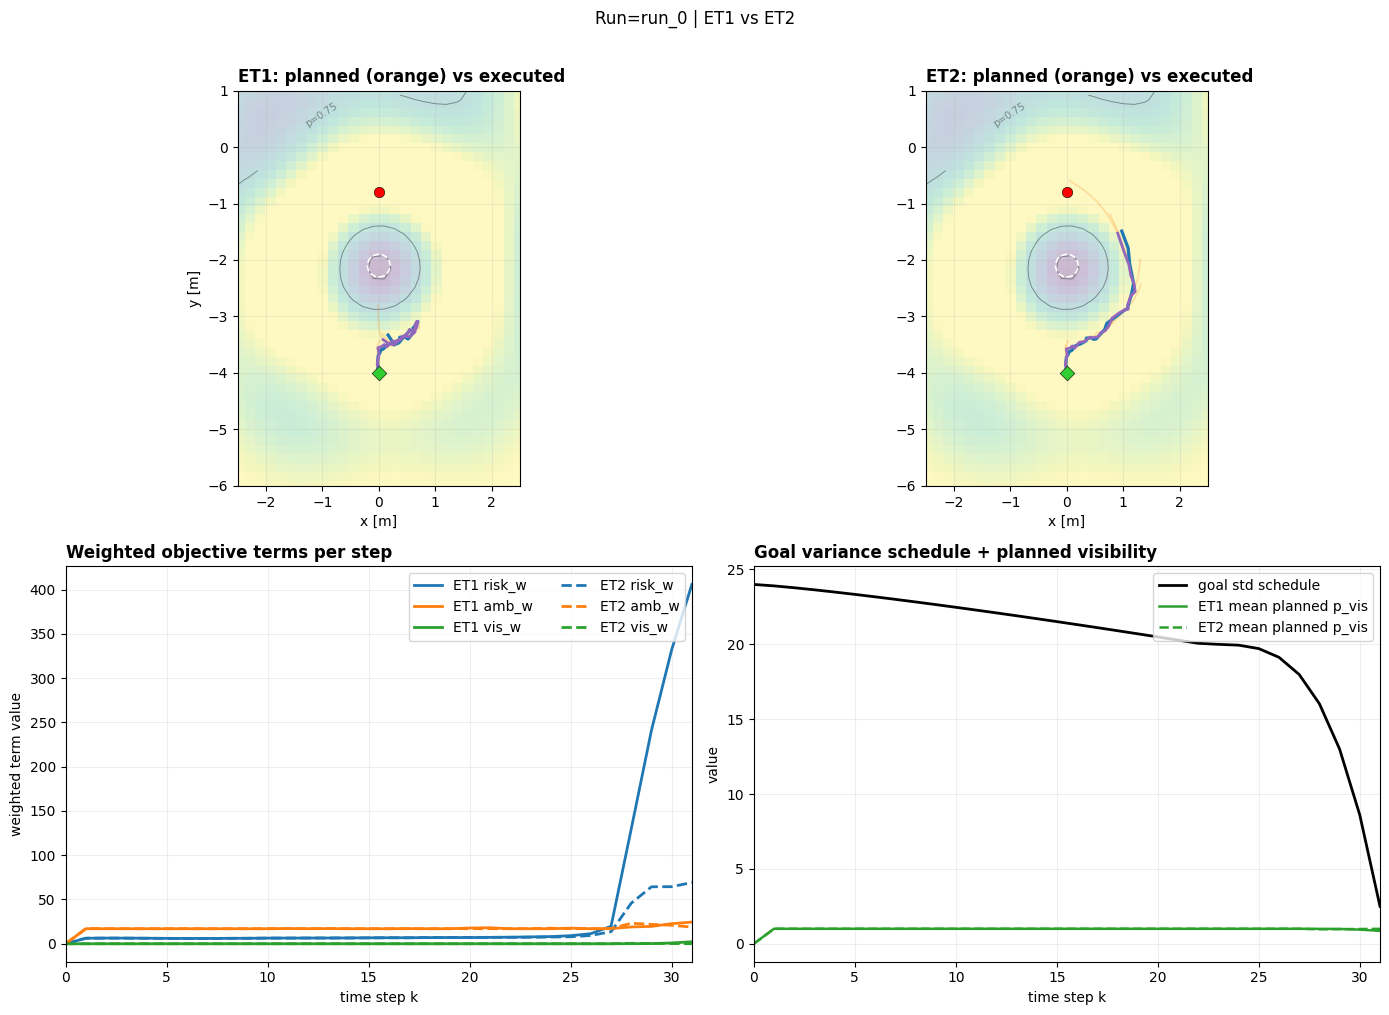

In [17]:
# Run ET1 vs ET2 and inspect behavior

ACTIVE_RUN_IDX = int(GOOD_RESULTS_PRESET['run_idx'])
SEED = int(GOOD_RESULTS_PRESET['seed'])
ZOOM_X = tuple(GOOD_RESULTS_PRESET['zoom_x'])
ZOOM_Y = tuple(GOOD_RESULTS_PRESET['zoom_y'])

install_visibility_run(ACTIVE_RUN_IDX)
res_et1 = run_single_experiment(method='ET1', seed=SEED, use_tqdm=False)
res_et2 = run_single_experiment(method='ET2', seed=SEED, use_tqdm=False)


def summarize_one(res):
    risk_total_raw = float(np.sum(res['risk_plan'][1:]))
    amb_total_raw = float(np.sum(res['amb_plan'][1:]))

    risk_total_w = float(np.sum(res['risk_w_plan'][1:]))
    amb_total_w = float(np.sum(res['amb_w_plan'][1:]))
    vis_total_w = float(np.sum(res['vis_w_plan'][1:]))
    u_total_w = float(np.sum(res['u_w_plan'][1:]))

    mean_p = float(np.mean(res['p_exec'][1:]))
    detect_rate = float(np.mean(res['detected'][1:]))
    control_eff = float(np.sum(np.sum(res['u'][1:]**2, axis=1)))

    return dict(
        method=res['method'],
        final_dist=res['final_dist'],
        risk_total_raw=risk_total_raw,
        amb_total_raw=amb_total_raw,
        raw_amb_to_risk=amb_total_raw / (risk_total_raw + 1e-9),
        risk_total_w=risk_total_w,
        amb_total_w=amb_total_w,
        vis_total_w=vis_total_w,
        u_total_w=u_total_w,
        weighted_total=risk_total_w + amb_total_w + vis_total_w + u_total_w,
        mean_p_vis=mean_p,
        detect_rate=detect_rate,
        control_effort=control_eff,
    )


s1 = summarize_one(res_et1)
s2 = summarize_one(res_et2)

print('=== Raw terms (for scale) ===')
for s in [s1, s2]:
    dom_raw = 'risk' if s['risk_total_raw'] > s['amb_total_raw'] else 'ambiguity'
    print(
        f"{s['method']}: raw risk={s['risk_total_raw']:.2f}, raw amb={s['amb_total_raw']:.2f}, "
        f"raw amb/risk={s['raw_amb_to_risk']:.3f}, dominant={dom_raw}"
    )

print('\n=== Weighted contributions (actual objective) ===')
for s in [s1, s2]:
    terms = {
        'risk_w': s['risk_total_w'],
        'amb_w': s['amb_total_w'],
        'vis_w': s['vis_total_w'],
        'u_w': s['u_total_w'],
    }
    dom = max(terms, key=terms.get)
    print(
        f"{s['method']}: risk_w={s['risk_total_w']:.2f}, amb_w={s['amb_total_w']:.2f}, "
        f"vis_w={s['vis_total_w']:.2f}, u_w={s['u_total_w']:.2f}, dominant={dom}"
    )

print('\n=== ET2 - ET1 deltas (weighted objective terms) ===')
print(f"delta risk_w: {s2['risk_total_w'] - s1['risk_total_w']:.2f}")
print(f"delta amb_w:  {s2['amb_total_w'] - s1['amb_total_w']:.2f}")
print(f"delta vis_w:  {s2['vis_total_w'] - s1['vis_total_w']:.2f}")
print(f"delta final_dist: {s2['final_dist'] - s1['final_dist']:.3f}")


def plot_planned_vs_executed(ax, res, title):
    ax.imshow(
        P_all,
        extent=[xmin, xmax, ymin, ymax],
        origin='lower',
        cmap='viridis',
        alpha=0.28,
        aspect='equal',
        zorder=0,
    )
    cs = ax.contour(X, Y, P_all, levels=[0.25, 0.5, 0.75], colors='k', linewidths=0.65, alpha=0.4)
    ax.clabel(cs, inline=True, fontsize=7, fmt='p=%.2f')

    ax.add_patch(plt.Circle(ACTIVE_VIS['occ_center'], ACTIVE_VIS['occ_radius'], fill=False, ls='--', lw=1.2, color='white', zorder=2))

    for k in range(1, len_trial, 3):
        pp = res['planned_paths'][k]
        if pp is not None:
            ax.plot(pp[:, 0], pp[:, 1], color='tab:orange', alpha=0.22, lw=1.2, zorder=2)

    ax.plot(res['true'][:, 0], res['true'][:, 1], color='tab:blue', lw=2.3, label='executed true', zorder=3)
    ax.plot(res['est'][:, 0], res['est'][:, 1], color='tab:purple', lw=2.0, label='executed belief', zorder=3)

    ax.scatter([start_state[0]], [start_state[1]], color='limegreen', marker='D', s=56, edgecolors='black', linewidths=0.4, label='start', zorder=5)
    ax.scatter([goal_state[0]], [goal_state[1]], color='red', s=56, edgecolors='black', linewidths=0.4, label='goal', zorder=5)

    ax.set_title(title, loc='left', fontweight='bold')
    ax.set_xlabel('x [m]')
    ax.set_xlim(*ZOOM_X)
    ax.set_ylim(*ZOOM_Y)
    ax.set_aspect('equal')


fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False)

plot_planned_vs_executed(axes[0, 0], res_et1, 'ET1: planned (orange) vs executed')
plot_planned_vs_executed(axes[0, 1], res_et2, 'ET2: planned (orange) vs executed')
axes[0, 0].set_ylabel('y [m]')

k_idx = np.arange(len_trial)
axes[1, 0].plot(k_idx, res_et1['risk_w_plan'], color='tab:blue', lw=2.0, label='ET1 risk_w')
axes[1, 0].plot(k_idx, res_et1['amb_w_plan'], color='tab:orange', lw=2.0, label='ET1 amb_w')
axes[1, 0].plot(k_idx, res_et1['vis_w_plan'], color='tab:green', lw=2.0, label='ET1 vis_w')
axes[1, 0].plot(k_idx, res_et2['risk_w_plan'], color='tab:blue', ls='--', lw=2.0, label='ET2 risk_w')
axes[1, 0].plot(k_idx, res_et2['amb_w_plan'], color='tab:orange', ls='--', lw=2.0, label='ET2 amb_w')
axes[1, 0].plot(k_idx, res_et2['vis_w_plan'], color='tab:green', ls='--', lw=2.0, label='ET2 vis_w')
axes[1, 0].set_title('Weighted objective terms per step', loc='left', fontweight='bold')
axes[1, 0].set_xlabel('time step k')
axes[1, 0].set_ylabel('weighted term value')
axes[1, 0].set_xlim(0, len_trial - 1)
axes[1, 0].legend(loc='upper right', ncol=2)

std_sched = np.array([goal_cov_at_step_np(k, len_trial)[1] for k in range(len_trial)])
axes[1, 1].plot(k_idx, std_sched, color='black', lw=2.0, label='goal std schedule')
axes[1, 1].plot(k_idx, res_et1['plan_p_mean'], color='tab:green', lw=1.8, label='ET1 mean planned p_vis')
axes[1, 1].plot(k_idx, res_et2['plan_p_mean'], color='tab:green', ls='--', lw=1.8, label='ET2 mean planned p_vis')
axes[1, 1].set_title('Goal variance schedule + planned visibility', loc='left', fontweight='bold')
axes[1, 1].set_xlabel('time step k')
axes[1, 1].set_ylabel('value')
axes[1, 1].set_xlim(0, len_trial - 1)
axes[1, 1].legend(loc='upper right')

fig.suptitle(f"Run={RUN_CONFIGS[ACTIVE_RUN_IDX]['name']} | ET1 vs ET2", y=1.01)
plt.tight_layout()
plt.show()


In [18]:
# Optional multi-seed ET1 vs ET2 summary

try:
    import pandas as pd
except Exception:
    pd = None

RUN_BATCH = False
N_SEEDS = 8
ACTIVE_RUN_IDX = int(GOOD_RESULTS_PRESET['run_idx'])

if not RUN_BATCH:
    print('Set RUN_BATCH=True to run multi-seed ET1/ET2 statistics.')
else:
    install_visibility_run(ACTIVE_RUN_IDX)

    rows = []
    for seed in range(N_SEEDS):
        for method in ['ET1', 'ET2']:
            res = run_single_experiment(method=method, seed=seed, use_tqdm=False)
            rows.append({
                'run': RUN_CONFIGS[ACTIVE_RUN_IDX]['name'],
                'seed': seed,
                **summarize_one(res),
            })

    if pd is not None:
        df = pd.DataFrame(rows).round(4)
        from IPython.display import display
        display(df)

        print('Grouped means by method:')
        display(df.groupby('method')[['final_dist', 'risk_total_raw', 'amb_total_raw', 'raw_amb_to_risk', 'risk_total_w', 'amb_total_w', 'vis_total_w', 'u_total_w', 'weighted_total', 'mean_p_vis', 'detect_rate', 'control_effort']].mean().round(4))
    else:
        for r in rows:
            print(r)


Set RUN_BATCH=True to run multi-seed ET1/ET2 statistics.
